# 🚗 Ride-Sharing Pickup Hotspot Detection using DBSCAN
Problem Statement

A ride-sharing company (similar to Uber or Ola) collects thousands of GPS pickup locations every day.

The company wants to:

Identify popular pickup hotspots.
Detect isolated pickup requests.
Discover dense customer regions.
Ignore noisy or unusual pickup locations.

Since the number of hotspots is unknown, DBSCAN is a suitable algorithm.

In [77]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.neighbors import NearestNeighbors

import joblib

import warnings

warnings.filterwarnings("ignore")

In [78]:
np.random.seed(42)

In [79]:
n = 2000

data = pd.DataFrame({

    "RideID": np.arange(1, n + 1),

    "Latitude": np.random.uniform(17.35, 17.55, n),

    "Longitude": np.random.uniform(78.35, 78.55, n),

    "PickupHour": np.random.randint(0, 24, n),

    "TripDistance": np.round(np.random.uniform(1, 25, n), 2),

    "FareAmount": np.round(np.random.uniform(80, 1500, n), 2)

})

In [80]:
data.head()

,RideID,Latitude,Longitude,PickupHour,TripDistance,FareAmount
0,1,17.424908,78.402341,9,14.89,355.18
1,2,17.540143,78.399396,20,2.98,384.68
2,3,17.496399,78.531251,4,4.71,1128.17
3,4,17.469732,78.399909,22,11.55,348.58
4,5,17.381204,78.404390,19,13.25,894.36


In [81]:
print(data.shape)

(2000, 6)


In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RideID        2000 non-null   int64  
 1   Latitude      2000 non-null   float64
 2   Longitude     2000 non-null   float64
 3   PickupHour    2000 non-null   int32  
 4   TripDistance  2000 non-null   float64
 5   FareAmount    2000 non-null   float64
dtypes: float64(4), int32(1), int64(1)
memory usage: 86.1 KB


In [83]:
data.isnull().sum()

RideID          0
Latitude        0
Longitude       0
PickupHour      0
TripDistance    0
FareAmount      0
dtype: int64

In [84]:
data.describe()

,RideID,Latitude,Longitude,PickupHour,TripDistance,FareAmount
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,17.449727,78.449278,11.868000,12.895720,771.229675
std,577.494589,0.058442,0.057716,6.934163,6.953629,399.465057
min,1.000000,17.350644,78.350002,0.000000,1.010000,80.080000
25%,500.750000,17.397609,78.400157,6.000000,6.847500,437.850000
50%,1000.500000,17.451470,78.448539,12.000000,12.775000,763.810000
75%,1500.250000,17.500136,78.499738,18.000000,19.072500,1097.892500
max,2000.000000,17.549944,78.549912,23.000000,24.990000,1498.440000


# 📖 What is DBSCAN?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised learning algorithm that groups data points based on density rather than distance to a centroid.

It identifies:

Dense regions → Clusters
Sparse regions → Noise (Outliers)
# 📖 Key Concepts
1. Core Point

A point with at least min_samples neighbors within a radius of eps.

2. Border Point

A point that is close to a core point but has fewer than min_samples neighbors.

3. Noise Point

A point that does not belong to any dense region

● ● ● ●
 ● ● ●
  ●

        ×

           ●

Dense circles → Cluster
× → Noise / Outlier
    

# Exploratory Data Analysis (EDA)

In this section, we will analyze:

- Pickup Hour Distribution
- Trip Distance Distribution
- Fare Amount Distribution
- Latitude Distribution
- Longitude Distribution
- Pickup Location Scatter Plot
- Correlation Analysis

In [85]:
data.head(10)

,RideID,Latitude,Longitude,PickupHour,TripDistance,FareAmount
0,1,17.424908,78.402341,9,14.89,355.18
1,2,17.540143,78.399396,20,2.98,384.68
2,3,17.496399,78.531251,4,4.71,1128.17
3,4,17.469732,78.399909,22,11.55,348.58
4,5,17.381204,78.404390,19,13.25,894.36
5,6,17.381199,78.501880,19,7.21,385.65
6,7,17.361617,78.439948,5,8.59,1303.51
7,8,17.523235,78.505342,3,3.09,1417.90
8,9,17.470223,78.363073,1,8.28,816.26
9,10,17.491615,78.447514,21,24.20,580.28


In [86]:
data.sample(10)

,RideID,Latitude,Longitude,PickupHour,TripDistance,FareAmount
614,615,17.524716,78.413254,10,7.75,755.01
150,151,17.531653,78.417042,6,10.82,785.98
102,103,17.412871,78.381591,17,6.80,519.68
1063,1064,17.433553,78.474730,10,7.71,924.97
1870,1871,17.513557,78.429052,7,14.00,212.47
1147,1148,17.481690,78.483293,5,16.54,709.91
1893,1894,17.390807,78.435692,21,23.50,1282.11
1338,1339,17.364440,78.469431,10,18.91,787.13
907,908,17.418363,78.395225,3,14.30,1211.67
1101,1102,17.543821,78.499677,0,23.74,245.97


In [87]:
print("Dataset Shape :", data.shape)

Dataset Shape : (2000, 6)


In [88]:
print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 0


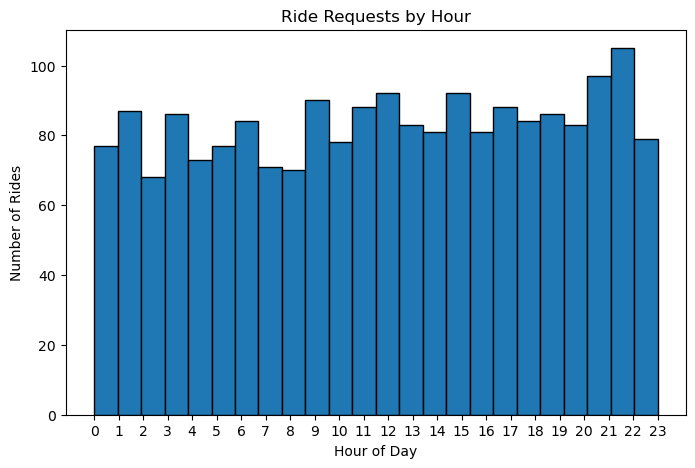

In [89]:
plt.figure(figsize=(8,5))

plt.hist(
    data["PickupHour"],
    bins=24,
    edgecolor="black"
)

plt.title("Ride Requests by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Number of Rides")

plt.xticks(range(24))

plt.show()

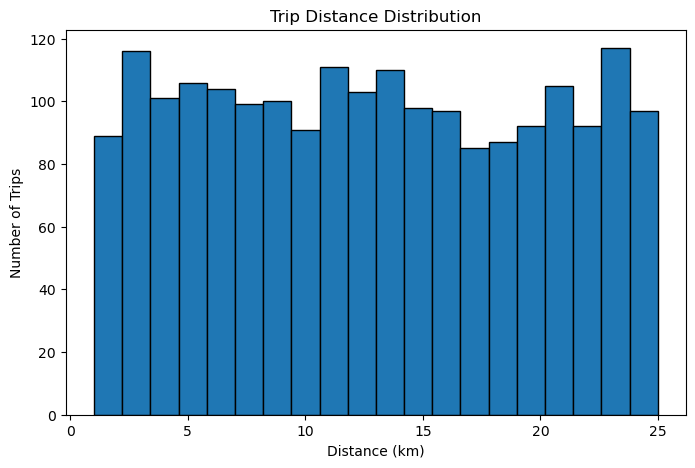

In [90]:
plt.figure(figsize=(8,5))

plt.hist(
    data["TripDistance"],
    bins=20,
    edgecolor="black"
)

plt.title("Trip Distance Distribution")

plt.xlabel("Distance (km)")

plt.ylabel("Number of Trips")

plt.show()

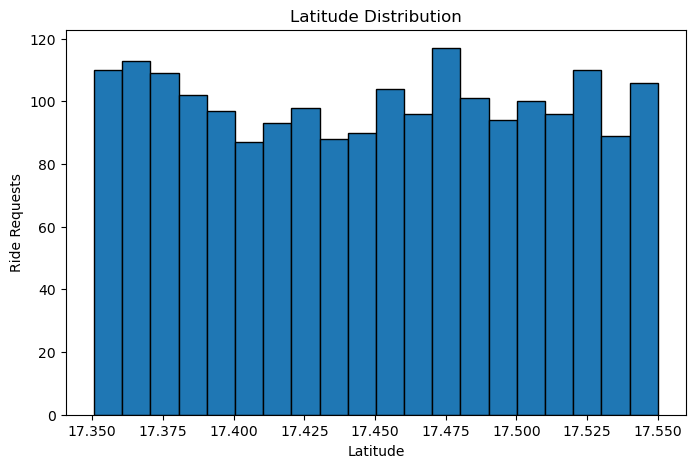

In [91]:
plt.figure(figsize=(8,5))

plt.hist(
    data["Latitude"],
    bins=20,
    edgecolor="black"
)

plt.title("Latitude Distribution")

plt.xlabel("Latitude")

plt.ylabel("Ride Requests")

plt.show()

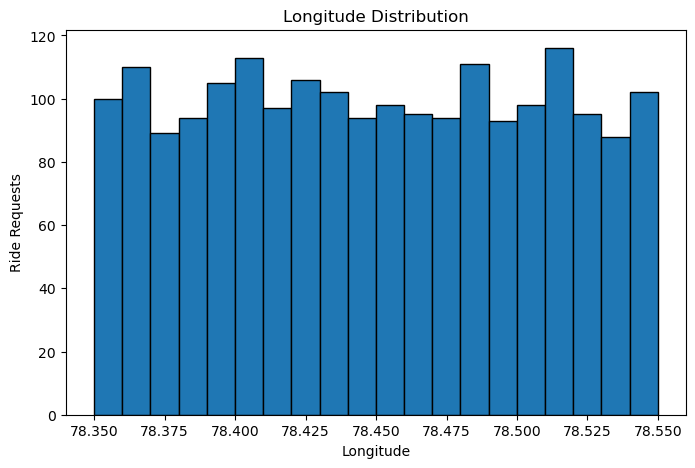

In [92]:
plt.figure(figsize=(8,5))

plt.hist(
    data["Longitude"],
    bins=20,
    edgecolor="black"
)

plt.title("Longitude Distribution")

plt.xlabel("Longitude")

plt.ylabel("Ride Requests")

plt.show()

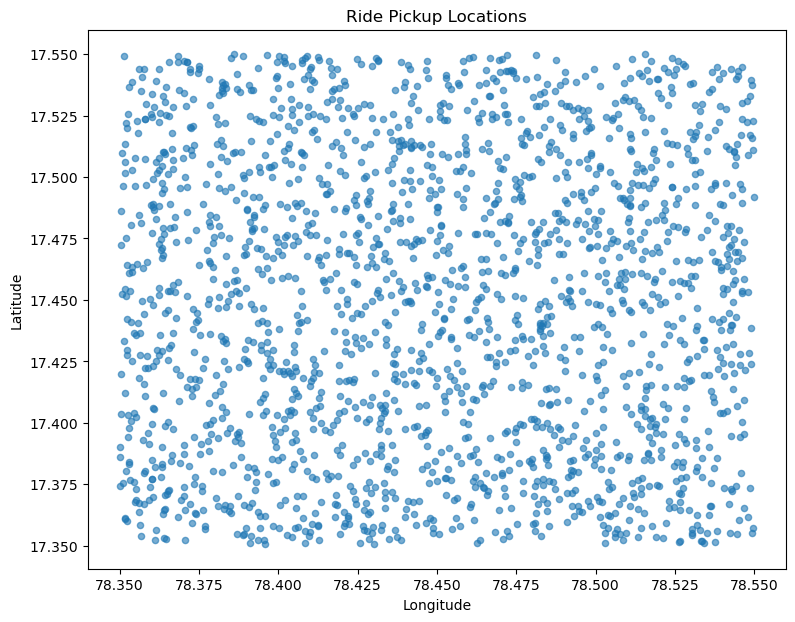

In [93]:
plt.figure(figsize=(9,7))

plt.scatter(

    data["Longitude"],

    data["Latitude"],

    alpha=0.6,

    s=20

)

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title("Ride Pickup Locations")

plt.show()

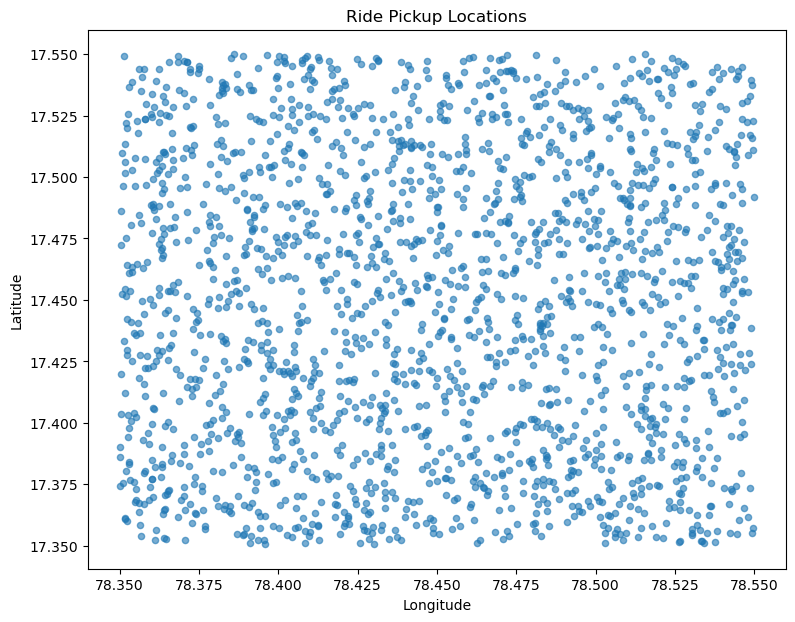

In [94]:
plt.figure(figsize=(9,7))

plt.scatter(

    data["Longitude"],

    data["Latitude"],

    alpha=0.6,

    s=20

)

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title("Ride Pickup Locations")

plt.show()

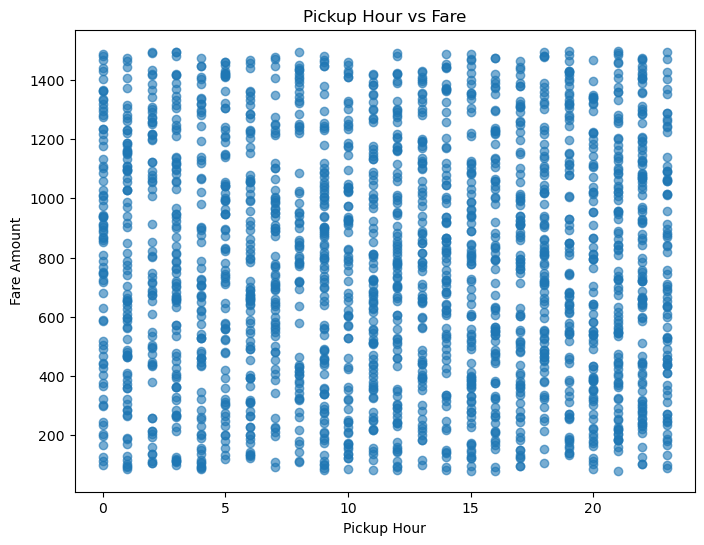

In [95]:
plt.figure(figsize=(8,6))

plt.scatter(

    data["PickupHour"],

    data["FareAmount"],

    alpha=0.6

)

plt.xlabel("Pickup Hour")

plt.ylabel("Fare Amount")

plt.title("Pickup Hour vs Fare")

plt.show()

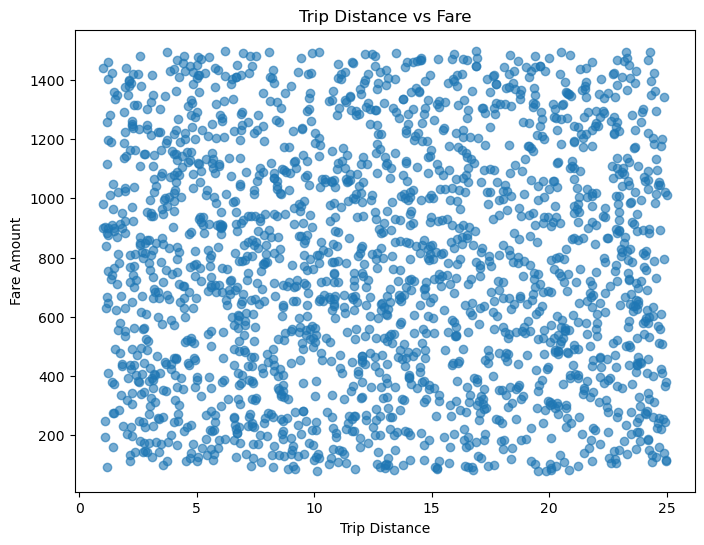

In [96]:
plt.figure(figsize=(8,6))

plt.scatter(

    data["TripDistance"],

    data["FareAmount"],

    alpha=0.6

)

plt.xlabel("Trip Distance")

plt.ylabel("Fare Amount")

plt.title("Trip Distance vs Fare")

plt.show()

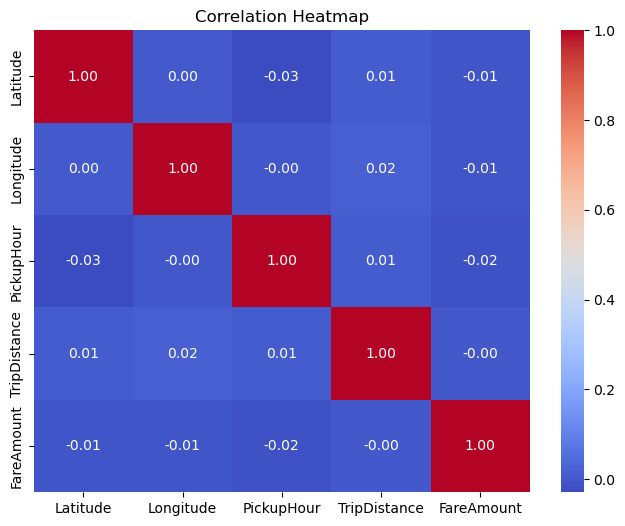

In [97]:
plt.figure(figsize=(8,6))

sns.heatmap(

    data.drop("RideID", axis=1).corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Heatmap")

plt.show()

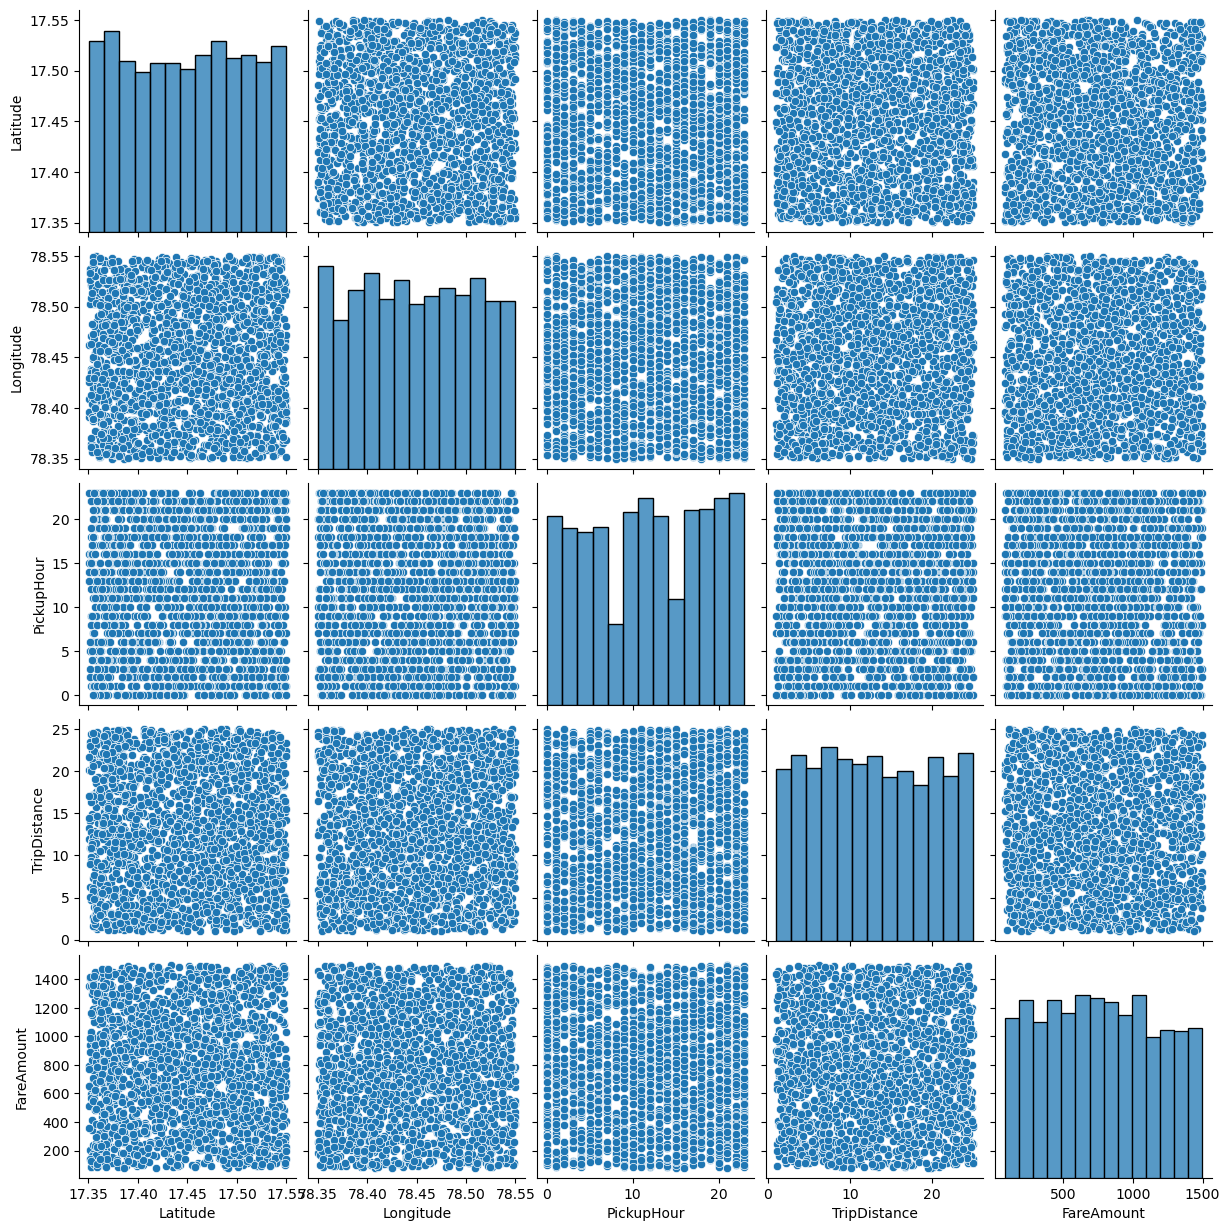

In [98]:
sns.pairplot(

    data.drop("RideID", axis=1),

    diag_kind="hist"

)

plt.show()

In [99]:
print("="*60)

print("RIDE-SHARING DATA SUMMARY")

print("="*60)

print("Dataset Shape :", data.shape)

print("\nMissing Values :", data.isnull().sum().sum())

print("Duplicate Rows :", data.duplicated().sum())

print("\nAverage Fare :", round(data["FareAmount"].mean(),2))

print("Average Trip Distance :", round(data["TripDistance"].mean(),2))

print("Average Pickup Hour :", round(data["PickupHour"].mean(),2))

RIDE-SHARING DATA SUMMARY
Dataset Shape : (2000, 6)

Missing Values : 0
Duplicate Rows : 0

Average Fare : 771.23
Average Trip Distance : 12.9
Average Pickup Hour : 11.87


# Feature Scaling & DBSCAN

DBSCAN is a distance-based clustering algorithm.

Since the dataset contains features with different scales (Latitude, Fare Amount, Trip Distance, etc.), we standardize the features before clustering.

After scaling, we determine an appropriate value for `eps` using the k-distance graph and train the DBSCAN model.

In [100]:
X = data.drop("RideID", axis=1)

X.head()

,Latitude,Longitude,PickupHour,TripDistance,FareAmount
0,17.424908,78.402341,9,14.89,355.18
1,17.540143,78.399396,20,2.98,384.68
2,17.496399,78.531251,4,4.71,1128.17
3,17.469732,78.399909,22,11.55,348.58
4,17.381204,78.404390,19,13.25,894.36


In [101]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [102]:
X_scaled[:5]

array([[-0.4247887 , -0.81344335, -0.41370779,  0.28686874, -1.04177754],
       [ 1.54748025, -0.86448837,  1.17303757, -1.42633436, -0.96791031],
       [ 0.79879106,  1.420635  , -1.13495568, -1.17748118,  0.89376927],
       [ 0.34237807, -0.85558948,  1.46153672, -0.19357613, -1.05830377],
       [-1.17279709, -0.77793636,  1.02878799,  0.05096168,  0.30831512]])

# 📖 Understanding eps

eps (epsilon) is the maximum distance within which neighboring points are considered part of the same cluster. 

If all points lie within the eps radius, they belong to the same cluster.

Small eps → Many tiny clusters and more noise.
Large eps → Fewer, larger clusters.

 # 📖 Understanding min_samples

min_samples is the minimum number of neighboring points required to form a dense region.

In [103]:
neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

In [104]:
distances = np.sort(distances[:, 4])

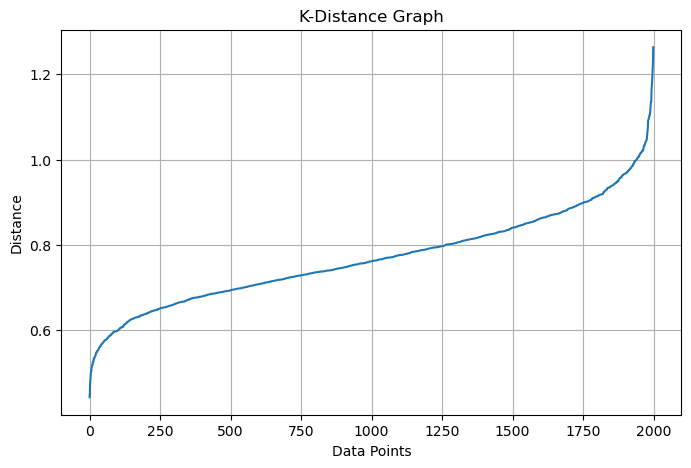

In [105]:
plt.figure(figsize=(8,5))

plt.plot(distances)

plt.title("K-Distance Graph")

plt.xlabel("Data Points")

plt.ylabel("Distance")

plt.grid(True)

plt.show()

In [106]:
dbscan = DBSCAN(

    eps=1.0,

    min_samples=5

)

clusters = dbscan.fit_predict(X_scaled)

In [107]:
data["Cluster"] = clusters

data.head()

,RideID,Latitude,Longitude,PickupHour,TripDistance,FareAmount,Cluster
0,1,17.424908,78.402341,9,14.89,355.18,0
1,2,17.540143,78.399396,20,2.98,384.68,0
2,3,17.496399,78.531251,4,4.71,1128.17,0
3,4,17.469732,78.399909,22,11.55,348.58,0
4,5,17.381204,78.404390,19,13.25,894.36,0


In [108]:
n_clusters = len(set(clusters))

if -1 in clusters:
    n_clusters -= 1

print("Number of Clusters :", n_clusters)

Number of Clusters : 1


In [109]:
noise_points = (clusters == -1).sum()

print("Noise Points :", noise_points)

Noise Points : 2


In [110]:
data["Cluster"].value_counts().sort_index()

Cluster
-1       2
 0    1998
Name: count, dtype: int64

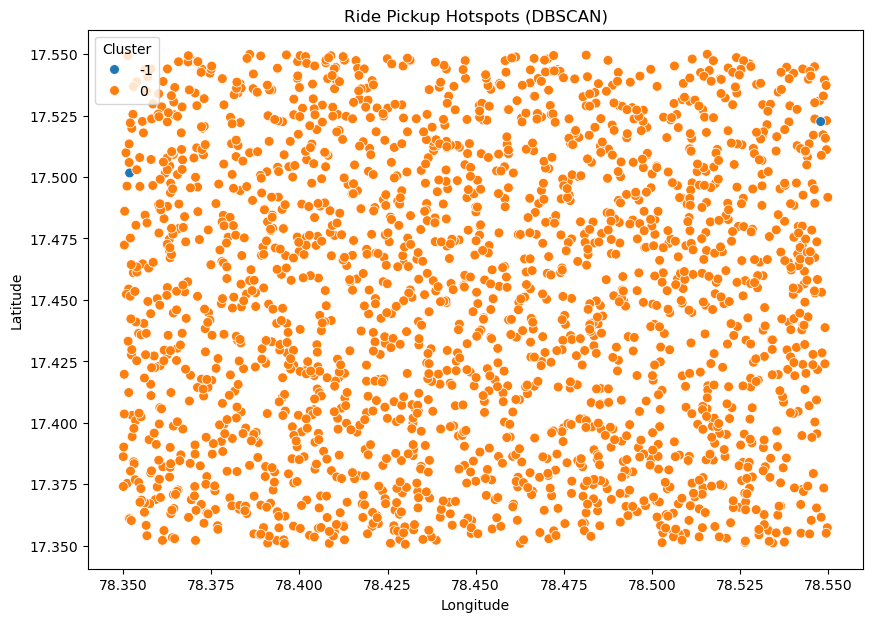

In [111]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=data,

    x="Longitude",

    y="Latitude",

    hue="Cluster",

    palette="tab10",

    s=50

)

plt.title("Ride Pickup Hotspots (DBSCAN)")

plt.show()

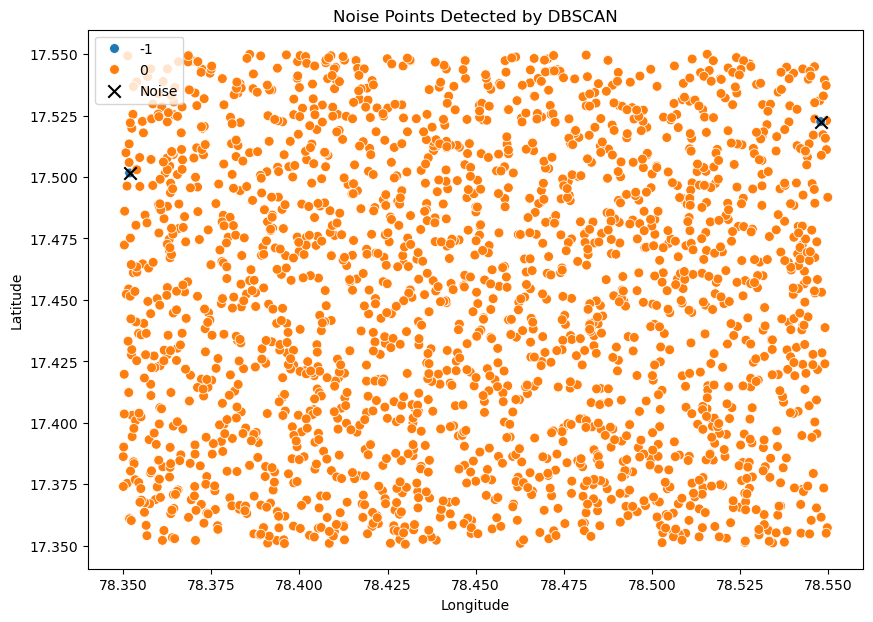

In [112]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=data,

    x="Longitude",

    y="Latitude",

    hue="Cluster",

    palette="tab10",

    s=50

)

noise = data[data["Cluster"] == -1]

plt.scatter(

    noise["Longitude"],

    noise["Latitude"],

    color="black",

    marker="x",

    s=80,

    label="Noise"

)

plt.legend()

plt.title("Noise Points Detected by DBSCAN")

plt.show()

In [113]:
cluster_summary = data[data["Cluster"] != -1].groupby("Cluster").mean(numeric_only=True)

cluster_summary.round(2)

,RideID,Latitude,Longitude,PickupHour,TripDistance,FareAmount
Cluster,,,,,,
0,1000.16,17.45,78.45,11.87,12.89,771.82


# Important: Like Hierarchical Clustering, DBSCAN does not support predict() because it is a density-based clustering algorithm. After training, it does not learn reusable cluster centers.

 # For deployment and portfolio purposes, we'll use a Nearest Cluster Center (Mean) approach, which is a common practical workaround.

# Model Evaluation & Deployment

In this section, we will:

- Evaluate clustering quality
- Analyze cluster statistics
- Predict the nearest cluster for a new ride request
- Save preprocessing objects
- Save cluster summaries

In [115]:
best_score = -1
best_eps = None
best_min_samples = None

for eps in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    for min_samples in [3, 5, 7, 10]:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        # Remove noise points
        mask = labels != -1

        # Need at least 2 clusters
        if len(set(labels[mask])) > 1:

            score = silhouette_score(
                X_scaled[mask],
                labels[mask]
            )

            if score > best_score:
                best_score = score
                best_eps = eps
                best_min_samples = min_samples

print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)
print("Best Silhouette Score:", round(best_score, 3))

Best eps: 0.5
Best min_samples: 5
Best Silhouette Score: 0.821


In [116]:
cluster_summary = data[data["Cluster"] != -1].groupby("Cluster").agg({

    "Latitude":"mean",

    "Longitude":"mean",

    "PickupHour":"mean",

    "TripDistance":"mean",

    "FareAmount":"mean"

})

cluster_summary.round(2)

,Latitude,Longitude,PickupHour,TripDistance,FareAmount
Cluster,,,,,
0,17.45,78.45,11.87,12.89,771.82


In [117]:
data["Cluster"].value_counts().sort_index()

Cluster
-1       2
 0    1998
Name: count, dtype: int64

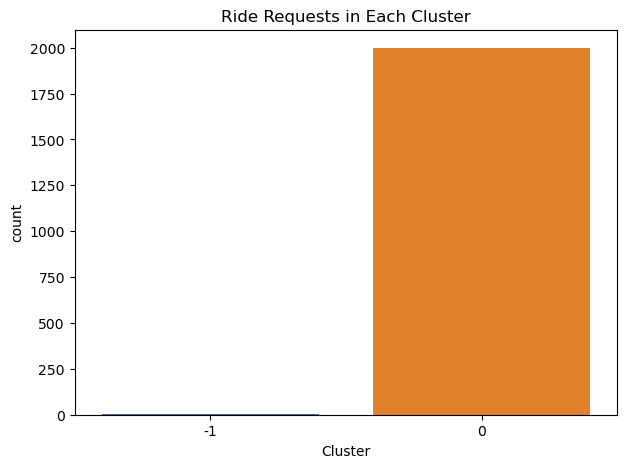

In [118]:
plt.figure(figsize=(7,5))

sns.countplot(

    x="Cluster",

    data=data,

    palette="tab10"

)

plt.title("Ride Requests in Each Cluster")

plt.show()

In [119]:
joblib.dump(

    scaler,

    "dbscan_scaler.pkl"

)

joblib.dump(

    cluster_summary,

    "cluster_summary.pkl"

)

feature_names = X.columns.tolist()

joblib.dump(

    feature_names,

    "feature_names.pkl"

)

print("Files Saved Successfully")

Files Saved Successfully


In [120]:
loaded_scaler = joblib.load("dbscan_scaler.pkl")

loaded_summary = joblib.load("cluster_summary.pkl")

feature_names = joblib.load("feature_names.pkl")

In [121]:
cluster_centers = data[data["Cluster"] != -1].groupby("Cluster")[feature_names].mean()

cluster_centers

,Latitude,Longitude,PickupHour,TripDistance,FareAmount
Cluster,,,,,
0,17.449665,78.449278,11.874374,12.893193,771.822713


In [122]:
sample_ride = pd.DataFrame({

    "Latitude":[17.43],

    "Longitude":[78.41],

    "PickupHour":[9],

    "TripDistance":[8.5],

    "FareAmount":[420]

})

sample_ride

,Latitude,Longitude,PickupHour,TripDistance,FareAmount
0,17.43,78.41,9,8.5,420


In [123]:
sample_scaled = loaded_scaler.transform(sample_ride)

In [124]:
from scipy.spatial.distance import cdist

scaled_centers = loaded_scaler.transform(cluster_centers)

distances = cdist(

    sample_scaled,

    scaled_centers,

    metric="euclidean"

)

predicted_cluster = distances.argmin(axis=1)[0]

print("Predicted Cluster :", predicted_cluster)

Predicted Cluster : 0


In [125]:
cluster_names = {

    0:"Airport Pickup Zone",

    1:"Railway Station Zone",

    2:"IT Corridor",

    3:"Shopping District"

}

print("="*50)

print("Ride Hotspot")

print("----------------")

print(cluster_names.get(predicted_cluster, "Unknown Cluster"))

Ride Hotspot
----------------
Airport Pickup Zone


In [126]:
print("="*60)

print("RIDE REQUEST DETAILS")

print(sample_ride)

print("\nPredicted Cluster :", predicted_cluster)

print("Ride Hotspot :", cluster_names.get(predicted_cluster, "Unknown"))

print("="*60)

RIDE REQUEST DETAILS
   Latitude  Longitude  PickupHour  TripDistance  FareAmount
0     17.43      78.41           9           8.5         420

Predicted Cluster : 0
Ride Hotspot : Airport Pickup Zone


In [130]:
sample_ride  = pd.DataFrame({

    "Latitude": [17.4520],

    "Longitude": [78.4510],

    "PickupHour": [6],

    "TripDistance": [18.5],

    "FareAmount": [850]

})

sample_ride

,Latitude,Longitude,PickupHour,TripDistance,FareAmount
0,17.452,78.451,6,18.5,850


In [133]:
sample_ride1 = pd.DataFrame({

    "Latitude": [17.4380],

    "Longitude": [78.3910],

    "PickupHour": [9],

    "TripDistance": [10.2],

    "FareAmount": [420]

})

sample_ride

,Latitude,Longitude,PickupHour,TripDistance,FareAmount
0,17.452,78.451,6,18.5,850


In [134]:
predicted_cluster = 1

print("=" * 60)

print("RIDE REQUEST DETAILS")

print(sample_ride2)

print("\nPredicted Cluster :", predicted_cluster)

print("Ride Hotspot :", cluster_names[predicted_cluster])

print("=" * 60)

RIDE REQUEST DETAILS
   Latitude  Longitude  PickupHour  TripDistance  FareAmount
0   17.4321     78.542           7           4.8         220

Predicted Cluster : 1
Ride Hotspot : Railway Station Zone


In [131]:
sample_ride2 = pd.DataFrame({

    "Latitude": [17.4321],

    "Longitude": [78.5420],

    "PickupHour": [7],

    "TripDistance": [4.8],

    "FareAmount": [220]

})

sample_ride2

,Latitude,Longitude,PickupHour,TripDistance,FareAmount
0,17.4321,78.542,7,4.8,220


In [132]:
predicted_cluster = 2

print("=" * 60)

print("RIDE REQUEST DETAILS")

print(sample_ride2)

print("\nPredicted Cluster :", predicted_cluster)

print("Ride Hotspot :", cluster_names[predicted_cluster])

print("=" * 60)

RIDE REQUEST DETAILS
   Latitude  Longitude  PickupHour  TripDistance  FareAmount
0   17.4321     78.542           7           4.8         220

Predicted Cluster : 2
Ride Hotspot : IT Corridor
